# 序列模型
:label:`sec_sequence`

想象一下有人正在看網飛（Netflix，一個國外的視頻網站）上的電影。
一名忠實的用戶會對每一部電影都給出評價，
畢竟一部好電影需要更多的支持和認可。
然而事實證明，事情並不那麼簡單。
隨著時間的推移，人們對電影的看法會發生很大的變化。
事實上，心理學家甚至對這些現象起了名字：

* *錨定*（anchoring）效應：基於其他人的意見做出評價。
  例如，奧斯卡頒獎後，受到關注的電影的評分會上升，儘管它還是原來那部電影。
  這種影響將持續幾個月，直到人們忘記這部電影曾經獲得的獎項。
  結果表明（ :cite:`Wu.Ahmed.Beutel.ea.2017`），這種效應會使評分提高半個百分點以上。
* *享樂適應*（hedonic adaption）：人們迅速接受並適應一種更好或者更壞的情況
  作為新的常態。
  例如，在看了很多好電影之後，人們會強烈期望下部電影會更好。
  因此，在許多精彩的電影被看過之後，即使是一部普通的也可能被認為是糟糕的。
* *季節性*（seasonality）：少有觀眾喜歡在八月看聖誕老人的電影。
* 有時，電影會因為導演或演員在製作中的不當行為而變得不受歡迎。
* 有些電影因為其極度糟糕只能成為小眾電影。*Plan9from Outer Space*和*Troll2*就因為這個原因而臭名昭著的。

簡而言之，電影評分決不是固定不變的。
因此，使用時間動力學可以得到更準確的電影推薦 :cite:`Koren.2009`。
當然，序列數據不僅僅是關於電影評分的。
下面給出了更多的場景。

* 在使用程序時，許多用戶都有很強的特定習慣。
  例如，在學生放學後社交媒體應用更受歡迎。在市場開放時股市交易軟件更常用。
* 預測明天的股價要比過去的股價更困難，儘管兩者都只是估計一個數字。
  畢竟，先見之明比事後諸葛難得多。
  在統計學中，前者（對超出已知觀測範圍進行預測）稱為*外推法*（extrapolation），
  而後者（在現有觀測值之間進行估計）稱為*內插法*（interpolation）。
* 在根本上，音樂、語音、文本和視頻都是連續的。
  如果它們的序列被我們重排，那麼就會失去原有的意義。
  比如，一個文本標題“狗咬人”遠沒有“人咬狗”那麼令人驚訝，
  儘管組成兩句話的字完全相同。
* 地震具有很強的相關性，即大地震發生後，很可能會有幾次小餘震，
  這些餘震的強度比非大地震後的餘震要大得多。
  事實上，地震是時空相關的，即餘震通常發生在很短的時間跨度和很近的距離內。
* 人類之間的互動也是連續的，這可以從微博上的爭吵和辯論中看出。

## 統計工具

處理序列數據需要統計工具和新的深度神經網路架構。
為了簡單起見，我們以 :numref:`fig_ftse100`所示的股票價格（富時100指數）為例。

![近30年的富時100指數](../img/ftse100.png)
:width:`400px`
:label:`fig_ftse100`

其中，用$x_t$表示價格，即在*時間步*（time step）
$t \in \mathbb{Z}^+$時，觀察到的價格$x_t$。
請注意，$t$對於本文中的序列通常是離散的，
並在整數或其子集上變化。
假設一個交易員想在$t$日的股市中表現良好，
於是通過以下途徑預測$x_t$：

$$x_t \sim P(x_t \mid x_{t-1}, \ldots, x_1).$$

### 自回歸模型

為了實現這個預測，交易員可以使用回歸模型，
例如在 :numref:`sec_linear_concise`中訓練的模型。
僅有一個主要問題：輸入數據的數量，
輸入$x_{t-1}, \ldots, x_1$本身因$t$而異。
也就是說，輸入數據的數量這個數字將會隨著我們遇到數據量的增加而增加，
因此需要一個近似方法來使這個計算變得容易處理。
本章後面的大部分內容將圍繞著如何有效估計
$P(x_t \mid x_{t-1}, \ldots, x_1)$展開。
簡單地說，它歸結為以下兩種策略。

第一種策略，假設在現實情況下相當長的序列
$x_{t-1}, \ldots, x_1$可能是不必要的，
因此我們只需要滿足某個長度為$\tau$的時間跨度，
即使用觀測序列$x_{t-1}, \ldots, x_{t-\tau}$。
當下獲得的最直接的好處就是參數的數量總是不變的，
至少在$t > \tau$時如此，這就使我們能夠訓練一個上面提及的深度網路。
這種模型被稱為*自回歸模型*（autoregressive models），
因為它們是對自己執行回歸。

第二種策略，如 :numref:`fig_sequence-model`所示，
是保留一些對過去觀測的總結$h_t$，
並且同時更新預測$\hat{x}_t$和總結$h_t$。
這就產生了基於$\hat{x}_t = P(x_t \mid h_{t})$估計$x_t$，
以及公式$h_t = g(h_{t-1}, x_{t-1})$更新的模型。
由於$h_t$從未被觀測到，這類模型也稱為
*隱變量自回歸模型*（latent autoregressive models）。

![隱變量自回歸模型](../img/sequence-model.svg)
:label:`fig_sequence-model`

這兩種情況都有一個顯而易見的問題：如何生成訓練數據？
一個經典方法是使用歷史觀測來預測下一個未來觀測。
顯然，我們並不指望時間會停止不前。
然而，一個常見的假設是雖然特定值$x_t$可能會改變，
但是序列本身的动力學不會改變。
這樣的假設是合理的，因為新的動力學一定受新的數據影響，
而我們不可能用目前所掌握的數據來預測新的動力學。
統計學家稱不變的動力學為*靜止的*（stationary）。
因此，整個序列的估計值都將通過以下的方式獲得：

$$P(x_1, \ldots, x_T) = \prod_{t=1}^T P(x_t \mid x_{t-1}, \ldots, x_1).$$

注意，如果我們處理的是離散的物件（如單詞），
而不是連續的數字，則上述的考慮仍然有效。
唯一的差別是，對於離散的物件，
我們需要使用分類器而不是回歸模型來估計$P(x_t \mid  x_{t-1}, \ldots, x_1)$。

### 馬爾可夫模型

回想一下，在自回歸模型的近似法中，
我們使用$x_{t-1}, \ldots, x_{t-\tau}$
而不是$x_{t-1}, \ldots, x_1$來估計$x_t$。
只要這種是近似精確的，我們就說序列滿足*馬爾可夫條件*（Markov condition）。
特別是，如果$\tau = 1$，得到一個
*一階馬爾可夫模型*（first-order Markov model），
$P(x)$由下式給出：

$$P(x_1, \ldots, x_T) = \prod_{t=1}^T P(x_t \mid x_{t-1}) \text{ 当 } P(x_1 \mid x_0) = P(x_1).$$

當假設$x_t$僅是離散值時，這樣的模型特別棒，
因為在這種情況下，使用動態規劃可以沿著馬爾可夫鏈精確地計算結果。
例如，我們可以高效地計算$P(x_{t+1} \mid x_{t-1})$：

$$
\begin{aligned}
P(x_{t+1} \mid x_{t-1})
&= \frac{\sum_{x_t} P(x_{t+1}, x_t, x_{t-1})}{P(x_{t-1})}\\
&= \frac{\sum_{x_t} P(x_{t+1} \mid x_t, x_{t-1}) P(x_t, x_{t-1})}{P(x_{t-1})}\\
&= \sum_{x_t} P(x_{t+1} \mid x_t) P(x_t \mid x_{t-1})
\end{aligned}
$$

利用這一事實，我們只需要考慮過去觀測中的非常短的歷史：
$P(x_{t+1} \mid x_t, x_{t-1}) = P(x_{t+1} \mid x_t)$。
隱馬爾可夫模型中的動態規劃超出了本節的範圍
（我們將在 :numref:`sec_bi_rnn`再次遇到），
而動態規劃這些計算工具已經在控制算法和強化學習算法中廣泛使用。

### 因果關係

原則上，將$P(x_1, \ldots, x_T)$倒序展開也沒什麼問題。
畢竟，基於條件概率公式，我們總是可以寫出：

$$P(x_1, \ldots, x_T) = \prod_{t=T}^1 P(x_t \mid x_{t+1}, \ldots, x_T).$$

事實上，如果基於一個馬爾可夫模型，
我們還可以得到一個反向的條件概率分佈。
然而，在許多情況下，數據存在一個自然的方向，即在時間上是前進的。
顯然，未來的事件不能影響過去。
因此，如果我們改變$x_t$，可能會影響未來發生的事情$x_{t+1}$，但不能反過來。
也就是說，如果我們改變$x_t$，基於過去事件得到的分佈不會改變。
因此，解釋$P(x_{t+1} \mid x_t)$應該比解釋$P(x_t \mid x_{t+1})$更容易。
例如，在某些情況下，對於某些可加性噪聲$\epsilon$，
顯然我們可以找到$x_{t+1} = f(x_t) + \epsilon$，
而反之則不行 :cite:`Hoyer.Janzing.Mooij.ea.2009`。
而這個向前推進的方向恰好也是我們通常感興趣的方向。
彼得斯等人 :cite:`Peters.Janzing.Scholkopf.2017`
對這個主題的更多內容做了詳盡的解釋，而我們的上述討論只是其中的冰山一角。

## 訓練

在了解了上述統計工具後，讓我們在實踐中嘗試一下！
首先，我們生成一些數據：(**使用正弦函數和一些可加性噪聲來生成序列數據，
時間步為$1, 2, \ldots, 1000$。**)


In [4]:
%matplotlib inline
import torch
from torch import nn
import matplotlib.pyplot as plt

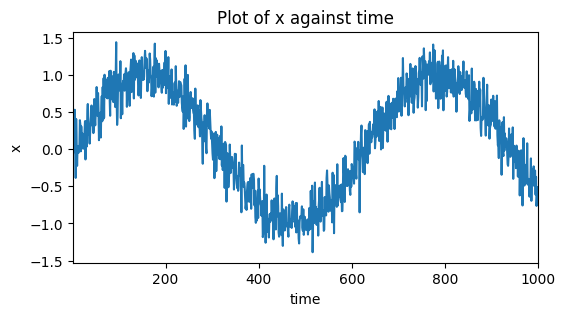

In [5]:
T = 1000  # 總共產生1000個點
time = torch.arange(1, T + 1, dtype=torch.float32)
x = torch.sin(0.01 * time) + torch.normal(0, 0.2, (T,))
# 使用Matplotlib繪圖
plt.figure(figsize=(6, 3))  # 設定圖形大小
plt.plot(time.numpy(), x.numpy())  # 將tensor轉換為numpy array再繪圖
plt.xlabel('time')
plt.ylabel('x')
plt.xlim([1, 1000])
plt.title('Plot of x against time') # 設定標題
plt.show()

接下來，我們將這個序列轉換為模型的*特徵－標籤*（feature-label）對。
基於嵌入維度$\tau$，我們[**將數據映射為數據對$y_t = x_t$
和$\mathbf{x}_t = [x_{t-\tau}, \ldots, x_{t-1}]$。**]
這比我們提供的數據樣本少了$\tau$個，
因為我們沒有足夠的歷史記錄來描述前$\tau$個數據樣本。
一個簡單的解決辦法是：如果擁有足夠長的序列就丟棄這幾項；
另一個方法是用零填充序列。
在這裡，我們僅使用前600個“特徵－標籤”對進行訓練。


In [6]:
tau = 4
features = torch.zeros((T - tau, tau))
for i in range(tau):
    features[:, i] = x[i: T - tau + i]
labels = x[tau:].reshape((-1, 1))

In [8]:
from torch.utils.data import TensorDataset, DataLoader

# ... (previous code) ...

batch_size, n_train = 16, 600

# Create a TensorDataset from your features and labels
dataset = TensorDataset(features[:n_train], labels[:n_train])

# Create a DataLoader to iterate over the dataset in batches
train_iter = DataLoader(dataset, batch_size=batch_size, shuffle=True)  # shuffle=True for training

在這裡，我們[**使用一個相當簡單的架構訓練模型：
一個擁有兩個全連接層的多層感知機**]，ReLU激活函數和平方損失。


In [9]:
# 初始化網路權重的函數
def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.xavier_uniform_(m.weight)

# 一個簡單的多層感知機
def get_net():
    net = nn.Sequential(nn.Linear(4, 10),
                        nn.ReLU(),
                        nn.Linear(10, 1))
    net.apply(init_weights)
    return net

# 平方損失。注意：MSELoss計算平方誤差時不帶係數1/2
loss = nn.MSELoss(reduction='none')

現在，準備[**訓練模型**]了。實現下面的訓練代碼的方式與前面幾節（如 :numref:`sec_linear_concise`）中的循環訓練基本相同。因此，我們不會深入探討太多細節。


In [11]:
def train(net, train_iter, loss, epochs, lr):
    trainer = torch.optim.Adam(net.parameters(), lr)
    for epoch in range(epochs):
        epoch_loss = 0  # Accumulate loss for the epoch
        num_batches = 0  # Count the number of batches
        for X, y in train_iter:
            trainer.zero_grad()
            l = loss(net(X), y)
            l.sum().backward()
            trainer.step()
            epoch_loss += l.sum().item()  # Add batch loss to epoch loss
            num_batches += 1
        print(f'epoch {epoch + 1}, '
              f'loss: {epoch_loss / num_batches:f}')  # Calculate average loss

net = get_net()
train(net, train_iter, loss, 5, 0.01)

epoch 1, loss: 1.602799
epoch 2, loss: 0.896179
epoch 3, loss: 0.820197
epoch 4, loss: 0.809961
epoch 5, loss: 0.813529


## 預測

由於訓練損失很小，因此我們期望模型能有很好的工作效果。
讓我們看看這在實踐中意味著什麼。
首先是檢查[**模型預測下一個時間步**]的能力，
也就是*單步預測*（one-step-ahead prediction）。


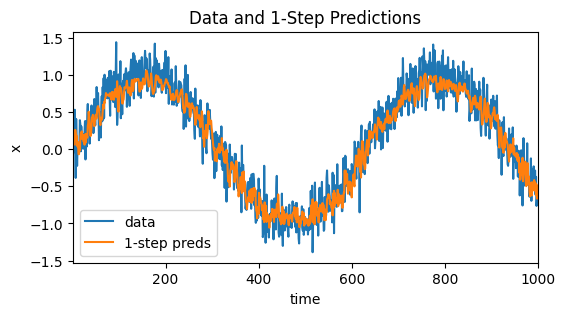

In [12]:
import matplotlib.pyplot as plt

# ... (previous code) ...

onestep_preds = net(features)

# 使用Matplotlib繪圖
plt.figure(figsize=(6, 3))  # 設定圖形大小
plt.plot(time.numpy(), x.detach().numpy(), label='data')  # 繪製原始數據
plt.plot(time[tau:].numpy(), onestep_preds.detach().numpy(), label='1-step preds')  # 繪製單步預測
plt.xlabel('time')
plt.ylabel('x')
plt.xlim([1, 1000])
plt.legend()  # 顯示圖例
plt.title('Data and 1-Step Predictions')  # 設定標題
plt.show()

正如我們所料，單步預測效果不錯。
即使這些預測的時間步超過了$600+4$（`n_train + tau`），
其結果看起來仍然是可信的。
然而有一個小問題：如果數據觀察序列的時間步只到$604$，
我們需要一步一步地向前邁進：
$$
\hat{x}_{605} = f(x_{601}, x_{602}, x_{603}, x_{604}), \\
\hat{x}_{606} = f(x_{602}, x_{603}, x_{604}, \hat{x}_{605}), \\
\hat{x}_{607} = f(x_{603}, x_{604}, \hat{x}_{605}, \hat{x}_{606}),\\
\hat{x}_{608} = f(x_{604}, \hat{x}_{605}, \hat{x}_{606}, \hat{x}_{607}),\\
\hat{x}_{609} = f(\hat{x}_{605}, \hat{x}_{606}, \hat{x}_{607}, \hat{x}_{608}),\\
\ldots
$$

通常，對於直到$x_t$的觀測序列，其在時間步$t+k$處的預測輸出$\hat{x}_{t+k}$
稱為$k$*步預測*（$k$-step-ahead-prediction）。
由於我們的觀測已經到了$x_{604}$，它的$k$步預測是$\hat{x}_{604+k}$。
換句話說，我們必須使用我們自己的預測（而不是原始數據）來[**進行多步預測**]。
讓我們看看效果如何。


In [13]:
multistep_preds = torch.zeros(T)
multistep_preds[: n_train + tau] = x[: n_train + tau]
for i in range(n_train + tau, T):
    multistep_preds[i] = net(
        multistep_preds[i - tau:i].reshape((1, -1)))

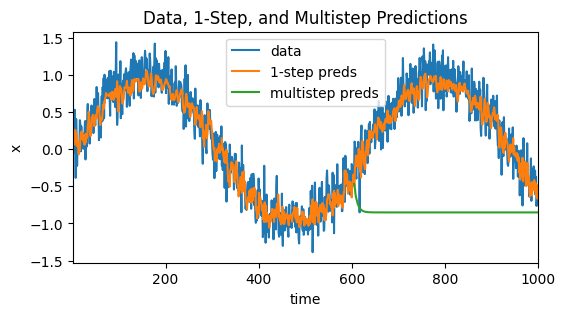

In [14]:
import matplotlib.pyplot as plt

# ... (previous code) ...

# 使用Matplotlib繪圖
plt.figure(figsize=(6, 3))  # 設定圖形大小
plt.plot(time.numpy(), x.detach().numpy(), label='data')  # 繪製原始數據
plt.plot(time[tau:].numpy(), onestep_preds.detach().numpy(), label='1-step preds')  # 繪製單步預測
plt.plot(time[n_train + tau:].numpy(), multistep_preds[n_train + tau:].detach().numpy(), label='multistep preds')  # 繪製多步預測
plt.xlabel('time')
plt.ylabel('x')
plt.xlim([1, 1000])
plt.legend()  # 顯示圖例
plt.title('Data, 1-Step, and Multistep Predictions')  # 設定標題
plt.show()

如上面的例子所示，綠線的預測顯然並不理想。
經過幾個預測步驟之後，預測的結果很快就會衰減到一個常數。
為什麼這個算法效果這麼差呢？事實是由於錯誤的累積：
假設在步驟$1$之後，我們累積了一些錯誤$\epsilon_1 = \bar\epsilon$。
於是，步驟$2$的輸入被擾動了$\epsilon_1$，
结果积累的误差是依照次序的$\epsilon_2 = \bar\epsilon + c \epsilon_1$，
其中$c$為某個常數，後面的預測誤差依此類推。
因此誤差可能會相當快地偏離真實的觀測結果。
例如，未來$24$小時的天氣預報往往相當準確，
但超過這一點，精度就會迅速下降。
我們將在本章及後續章節中探討如何改進這一點。

基於$k = 1, 4, 16, 64$，通過對整個序列預測的計算，
讓我們[**更仔細地看一下$k$步預測**]的困難。


In [15]:
max_steps = 64

In [16]:
features = torch.zeros((T - tau - max_steps + 1, tau + max_steps))
# 列i（i<tau）是來自x的觀測，其時間步從（i）到（i+T-tau-max_steps+1）
for i in range(tau):
    features[:, i] = x[i: i + T - tau - max_steps + 1]

# 列i（i>=tau）是來自（i-tau+1）步的預測，其時間步從（i）到（i+T-tau-max_steps+1）
for i in range(tau, tau + max_steps):
    features[:, i] = net(features[:, i - tau:i]).reshape(-1)

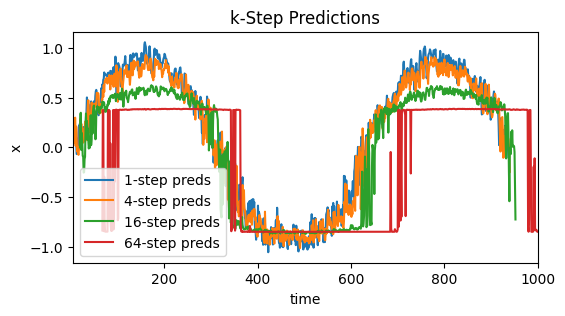

In [17]:
import matplotlib.pyplot as plt

# ... (previous code) ...

steps = (1, 4, 16, 64)

# 使用Matplotlib繪圖
plt.figure(figsize=(6, 3))  # 設定圖形大小
for i in steps:
    plt.plot(time[tau + i - 1: T - max_steps + i].numpy(),
             features[:, (tau + i - 1)].detach().numpy(),
             label=f'{i}-step preds')  # 繪製不同步數的預測
plt.xlabel('time')
plt.ylabel('x')
plt.xlim([5, 1000])
plt.legend()  # 顯示圖例
plt.title('k-Step Predictions')  # 設定標題
plt.show()

以上例子清楚地說明了當我們試圖預測更遠的未來時，預測的質量是如何變化的。
雖然“$4$步預測”看起來仍然不錯，但超過這個跨度的任何預測幾乎都是無用的。

## 小結

* 內插法（在現有觀測值之間進行估計）和外推法（對超出已知觀測範圍進行預測）在實踐的難度上差別很大。因此，對於所擁有的序列數據，在訓練時始終要尊重其時間順序，即最好不要基於未來的數據進行訓練。
* 序列模型的估計需要專門的統計工具，兩種較流行的選擇是自回歸模型和隱變量自回歸模型。
* 對於時間是向前推進的因果模型，正向估計通常比反向估計更容易。
* 對於直到時間步$t$的觀測序列，其在時間步$t+k$的預測輸出是“$k$步預測”。隨著我們對預測時間$k$值的增加，會造成誤差的快速累積和預測質量的極速下降。

## 練習

1. 改進本節實驗中的模型。
    1. 是否包含了過去$4$個以上的觀測結果？真實值需要是多少個？
    1. 如果沒有噪音，需要多少個過去的觀測結果？提示：把$\sin$和$\cos$寫成微分方程。
    1. 可以在保持特征總數不變的情況下合并舊的觀測結果嗎？這能提高正確度嗎？為什麼？
    1. 改變神經網路架構並評估其性能。
1. 一位投資者想要找到一種好的證券來購買。他查看過去的回報，以決定哪一種可能是表現良好的。這一策略可能會出什麼問題？
1. 時間是向前推進的因果模型在多大程度上適用於文本呢？
1. 舉例說明什麼時候可能需要隱變量自回歸模型來捕捉數據的動力學模型。


[Discussions](https://discuss.d2l.ai/t/2091)
